<p align="center">
  <img src="Food class_2.png" alt="Food class_2" width="500">
</p>

A popular social media platform dedicated to food enthusiasts wants to improve user engagement by adding advanced image recognition features. As a machine learning engineer, you are tasked with developing a food image classification system using Hugging Face's state-of-the-art models. This system will automatically identify and categorize food items in user-uploaded photos, allowing for better content organization and personalized food content recommendations.

Your responsibility is to develop a robust food category image classification system using pre-trained models from Hugging Face.

The goal is to enhance user interaction by providing accurate food classification, enabling users to easily find and engage with content related to their favorite foods, and improving the overall experience on the platform.

In this dynamic project, we leverage the power of PyTorch and transformers, utilizing an open-source model from Hugging Face as the backbone of our solution.

## Guide:

### High Level Instructions:
The social media company hired you to help them perform image classification to identify food categories. A sample image has been provided in the Food Pictures directory. You start by finding answers to the following questions:

* What model would you use for this image classification task? Search for a Hugging Face model suitable for the task and use it to get the probabilities of different food categories corresponding to the sample image provided. Store the result in a list of dictionaries named `class_scores`, containing the food categories and their probability.

* Classify the sample food image: identify the label of the food category with the highest probability for the uploaded image. Store the result as a string named `highest_probability_class`.

In [2]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

from transformers import pipeline
from transformers.utils import logging
# Only show error messages from the transformers library to reduce the amount of log output
logging.set_verbosity_error()

import warnings
# Ignore all Python warnings to keep the output clean
warnings.filterwarnings("ignore")


In [3]:
# 1. Load a food image and convert it to RGB format

# Extra credit: opening all images in designated folder instead of just one
d = Path(r"HuggingFaceImaging"); exts = (".jpg",".jpeg",".png",".bmp",".gif",".tif",".tiff",".webp")

# files = [p.name for p in Path(r"C:\Users\chanc\Documents\Hugging Face Models\Food Image Classification/").iterdir() if p.is_file() and p.name.endswith(exts)]
files = [str(p) for p in d.iterdir() if p.is_file() and p.suffix.lower() in exts]

# file_names = [os.path.join(d,f) for f in os.listdir(d) if f.lower().endswith(exts)]
# food_img = [Image.open(files)]
food_img = [Image.open(os.path.join(d, f)) for f in os.listdir(d) if f.lower().endswith(exts)]


# for only one image (from original project)

# food_img = Image.open(r"C:\Users\chanc\Documents\Hugging Face Models\Food Image Classification/food_1.png")


# Helper function to convert image to RGB format
def convert_to_rgb(image):
    """
    Converts an image to RGB format.

    Parameters:
    image (PIL.Image): An image object.

    Returns:
    PIL.Image: Image object in RGB format.
    """
    for i in image:
        i.convert('RGB')
    
    return image


image = convert_to_rgb(food_img)

# print(image)
# print(food_img)
# print(files)


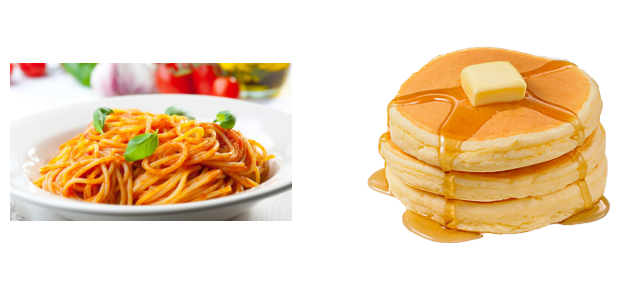

In [4]:
# 2. Display the uploaded image


# def plot_each(images):
#     for idx, val in enumerate(files):
#         print([val])
#         plt.imshow(image)
#         plt.axis('off')
#         # plt.show()

# plot_each(files)


fig, axs = plt.subplots(1, len(files), figsize=(4*len(files), 4))
for ax, f in zip((axs if len(files)>1 else [axs]), files):
    ax.imshow(plt.imread(f)); ax.axis('off')

# plt.imshow(image);plt.axis('off')

In [5]:
# 3. Find the pre-trained model on Hugging Face and create its instance

# Link to hugging face model search: https://huggingface.co/models?sort=modified&search=food+classification

# 4. Load and save pre-trained image classification model

model = pipeline("image-classification", model="Kaludi/food-category-classification-v2.0")
modelId = 3353292434

model.save_pretrained(save_directory=r"HuggingFaceImaging")


# pipe = pipeline("text-classification", model="jcharlie39/learn_Hugging_Face_Food_Classification_Model_using_Distilbert_Uncased_Model")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/348M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/388 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/348M [00:00<?, ?B/s]

In [6]:
# 5. Get the probablilites across different food categories

class_scores = model(image)

print(class_scores)


[[{'label': 'Noodles', 'score': 0.9994304776191711}, {'label': 'Rice', 'score': 0.00020329064864199609}, {'label': 'Soup', 'score': 0.00016876096196938306}, {'label': 'Egg', 'score': 6.624410161748528e-05}, {'label': 'Vegetable', 'score': 4.0434162656310946e-05}], [{'label': 'Dessert', 'score': 0.8499079942703247}, {'label': 'Dairy', 'score': 0.11044489592313766}, {'label': 'Bread', 'score': 0.03713589161634445}, {'label': 'Egg', 'score': 0.0014398811617866158}, {'label': 'Soup', 'score': 0.0003846193721983582}]]


In [7]:
# 6. Identify and print the highest probability food category

# def most_likely_nom(scores):
#     highest_scores = max(scores, key=(lambda x: x['score']))
#     return highest_scores

# Function to handle many lists instead of just the original one list for one pic
def most_likely_nom_multi(data):
    return [max(inner, key=lambda d: d['score'])['label'] for inner in data]


highest_probability_class = most_likely_nom_multi(class_scores)

print(f"Predicted food category: {highest_probability_class}")


Predicted food category: ['Noodles', 'Dessert']


## Hints

### Load a food image, convert it to RGB format, and display uploaded image
* First, create an `.open()` object from the PIL library to read the image file. This object is responsible for opening the image.
* Specify the location of the image file as a string. For example, to upload an image from the Food Pictures directory, you might use the path Food Pictures/food_1.png.
* After reading the image file, use the helper function, `convert_to_rgb`, to ensure the image is in RGB format. This step is crucial as it standardizes the image format, making it compatible with most image processing and machine learning models.
* Save the resulting image object as image.
* Use the `.imshow()` function from the matplotlib.pyplot module to display the image. This function takes the image object as an argument and renders it in a plot window.
* To enhance the visual presentation of the image, hide the plot axes using the `.axis('off')` function from 
matplotlib.pyplot. This function removes the axis lines, labels, and ticks from the plot, providing a cleaner view of the image.


### Find the pre-trained image classification model on Hugging face, create its instance, then load and save the model. 
* Visit the Hugging Face Model Hub.
* First, filter the models to show only those related to image classification by selecting the appropriate filters or categories on the website.
* Use the search bar to look for models related to food category classification by typing keywords like food category(s).
* Review the available models and select one that meets your needs. For this guide, we will use the most trending model with the ID Kaludi/food-category-classification-v2.0.
* Once you have selected the model, note down its unique model ID.
* Define the model ID in your code to use this pre-trained model for food category classification.
* Ensure you call the model ID as modelId in your code for consistency and clarity.
* Use the `.pipeline()` function from the transformers library. Call the `.pipeline()` function with the task type image-classification and pass the model ID to load the specific pre-trained model.
* Assign the loaded model to a variable named model.
* Determine and specify the local directory where you want to save the model.
* Ensure the specified directory exists or is created if it doesn't.
* Use the `.save_pretrained()` method on the model object with the save_directory parameter to save the model to the specified directory. This method takes care of saving all necessary files.


### Get the probabilities of your images across different food categories
* Use the model instance (which you previously loaded) to classify the image.
* Pass the image object to the model by calling the model instance with the image as the argument. This will trigger the model to process the image and generate classification scores.
* The model will return a list of dictionaries, where each dictionary contains a food category and its corresponding probability score.
* Store the results in a variable, such as class_scores, to hold the classification outcomes.
* Print the class_scores variable to display the probabilities of different food categories. This output will help you understand which categories the model has identified and the probability level for each category.


### Identify and print the highest probability food category
* Use the `max()` function to find the dictionary with the highest score in the class_scores list.
* Specify a key function `(lambda x: x['score'])` to compare the scores within the dictionaries.
* Store the result in the variable highest_probability_class
* Print the label using a formatted string to display the predicted food category. Pass the string `f"Predicted food category: {highest_probability_class['label']}"` to the 
`print()` function for clear output.

